# Set up à run à chaque fois


In [2]:
import torch
import torchvision
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2
import os
import time

from matplotlib.animation import FuncAnimation


#environment set up
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())



PyTorch version: 2.2.2
Torchvision version: 0.17.2
CUDA is available: False


In [3]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [ ]:
"""import sys
sys.path.append("..")
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

device = "mps"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

if device == "mps":
    sam = sam.float()

mask_generator = SamAutomaticMaskGenerator(sam)"""

In [9]:
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry
sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h_4b8939.pth")
mask_generator = SamAutomaticMaskGenerator(sam)

In [10]:
#plot les masques
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

# Le code

## visualisation de base


In [14]:
dic_path = '/Users/inesgabert/Documents/LBE/image_processing/data/SBW25WTGFP_CAAIPTG_1_100cell_droplet-04_processed_fbnotebook/001.jpg'
fluo_path = 'SBW25WTGFP_CAAIPTG_1_100cell_droplet-04/SBW25WTGFP_CAAIPTG_1_100cell_droplet-04_t091_EGFP_ORG.tif'

In [11]:
# prompt: fais une fonction qui fait une roi d'une image avec en entrée la path de l'image et la taille de la roi


def extract_roi(image_path, x_min, y_min, x_max, y_max):
    """
    Extracts a region of interest (ROI) from an image.

    Args:
        image_path: The path to the image file.
        x_min: The minimum x-coordinate of the ROI.
        y_min: The minimum y-coordinate of the ROI.
        x_max: The maximum x-coordinate of the ROI.
        y_max: The maximum y-coordinate of the ROI.

    Returns:
        The ROI as a NumPy array, or None if the image cannot be read or the ROI coordinates are invalid.
    """
    image = cv2.imread(image_path)

    if image is None:
        print(f"Erreur : Impossible de lire l'image à partir du chemin : {image_path}")
        return None
    image_height, image_width = image.shape[:2]
    
    if not (0 <= x_min < x_max <= image_width and 0 <= y_min < y_max <= image_height):
        print("Erreur : Les coordonnées de la ROI sont invalides.")
        return None

    roi = image[y_min:y_max, x_min:x_max]
    return roi

def show_roi(image_path, roi):
    """
    Displays the original image and the extracted ROI side-by-side.
    """
    image = cv2.imread(image_path)
    if image is None or roi is None:
        return

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Image originale")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
    plt.title("ROI")
    plt.axis('off')

    plt.show()


In [15]:
plot_dic = True
x_min, y_min, x_max, y_max = 0, 0, 1100, 800
dic_roi = extract_roi(dic_path, x_min, y_min, x_max, y_max)


if plot_dic == True:
    show_roi(dic_path, dic_roi)

Erreur : Les coordonnées de la ROI sont invalides.


In [16]:
dic_roi = cv2.imread(dic_path)

## générer masques

### masques de base

In [17]:
masks = mask_generator.generate(dic_roi)
print(len(masks)) # temps d'exécution en local: 5min

70


### masques de base stockés pour ROI 2600, 1700 coin à gauche

In [7]:

# Stocker le tableau dans un fichier
# np.save('masks.npy', masks)

# Charger le tableau depuis le fichier
masks_chargees = np.load('masks.npy', allow_pickle=True)
masks = masks_chargees

### masques tunés: pas fructueux pour l'instant

In [ ]:
mask_generator_2 = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=100,  # Requires open-cv to run post-processing
)

## tri des masques et roi de l'image

In [19]:
def calculate_circularity(mask):
    """
    Calculate the circularity of a segmented region using mask properties.

    Args:
        mask: Dictionary containing mask properties, including 'segmentation' (binary array) and 'area'.

    Returns:
        Circularity value (float) or None if the mask is invalid.
    """
    area = mask.get('area', None)
    if area is None or area == 0:
        print("Invalid or zero area in mask.")
        return None

    segmentation = mask['segmentation'].astype(np.uint8)
    contours, _ = cv2.findContours(segmentation, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        print("No contours found in the mask.")
        return None

    # Utiliser le plus grand contour pour calculer le périmètre
    largest_contour = max(contours, key=cv2.contourArea)
    perimeter = cv2.arcLength(largest_contour, True)

    if perimeter == 0:
        print("Perimeter is zero, cannot calculate circularity.")
        return None

    # Calculer la circularité
    circularity = (4 * np.pi * area) / (perimeter ** 2)
    return circularity



In [11]:
def plot_circularity_validation(dic_roi, masks, circularity_threshold=0.8):
    """
    Affiche jusqu'à 5 masques valides et 10 masques non valides superposés sur l'image DIC.

    Args:
        dic_roi: Image DIC (déjà extraite sous forme de tableau NumPy).
        masks: Liste de masques générés.
        circularity_threshold: Seuil de circularité pour valider un masque.
    """
    if dic_roi is None:
        print("Erreur : L'image DIC (dic_roi) est invalide.")
        return

    # Séparer les masques valides et non valides
    valid_masks = []
    invalid_masks = []

    for mask in masks:
        circularity = calculate_circularity(mask)
        if circularity is not None and circularity >= circularity_threshold:
            valid_masks.append(mask)
        else:
            invalid_masks.append(mask)

        # Limiter à 5 masques valides et 10 masques invalides
        if len(valid_masks) >= 10 and len(invalid_masks) >= 10:
            break

    # Afficher les masques valides
    plt.figure(figsize=(15, 10))
    for i, mask in enumerate(valid_masks[:10]):
        plt.subplot(4, 5, i + 1)
        plt.imshow(dic_roi)
        segmentation = mask['segmentation']
        plt.imshow(segmentation, cmap='Reds', alpha=0.5)  # Superposer le masque en rouge
        plt.title(f"Valid Mask {i + 1}")
        plt.axis('off')

    # Afficher les masques non valides
    for i, mask in enumerate(invalid_masks[:10]):
        plt.subplot(4, 5, i + 11)
        plt.imshow(dic_roi)
        segmentation = mask['segmentation']
        plt.imshow(segmentation, cmap='Blues', alpha=0.5)  # Superposer le masque en bleu
        plt.title(f"Invalid Mask {i + 1}")
        plt.axis('off')
    plt.suptitle("Valid and Invalid Masks for circularity threshold: " + str(circularity_threshold), fontsize=16)
    plt.tight_layout()
    plt.show()


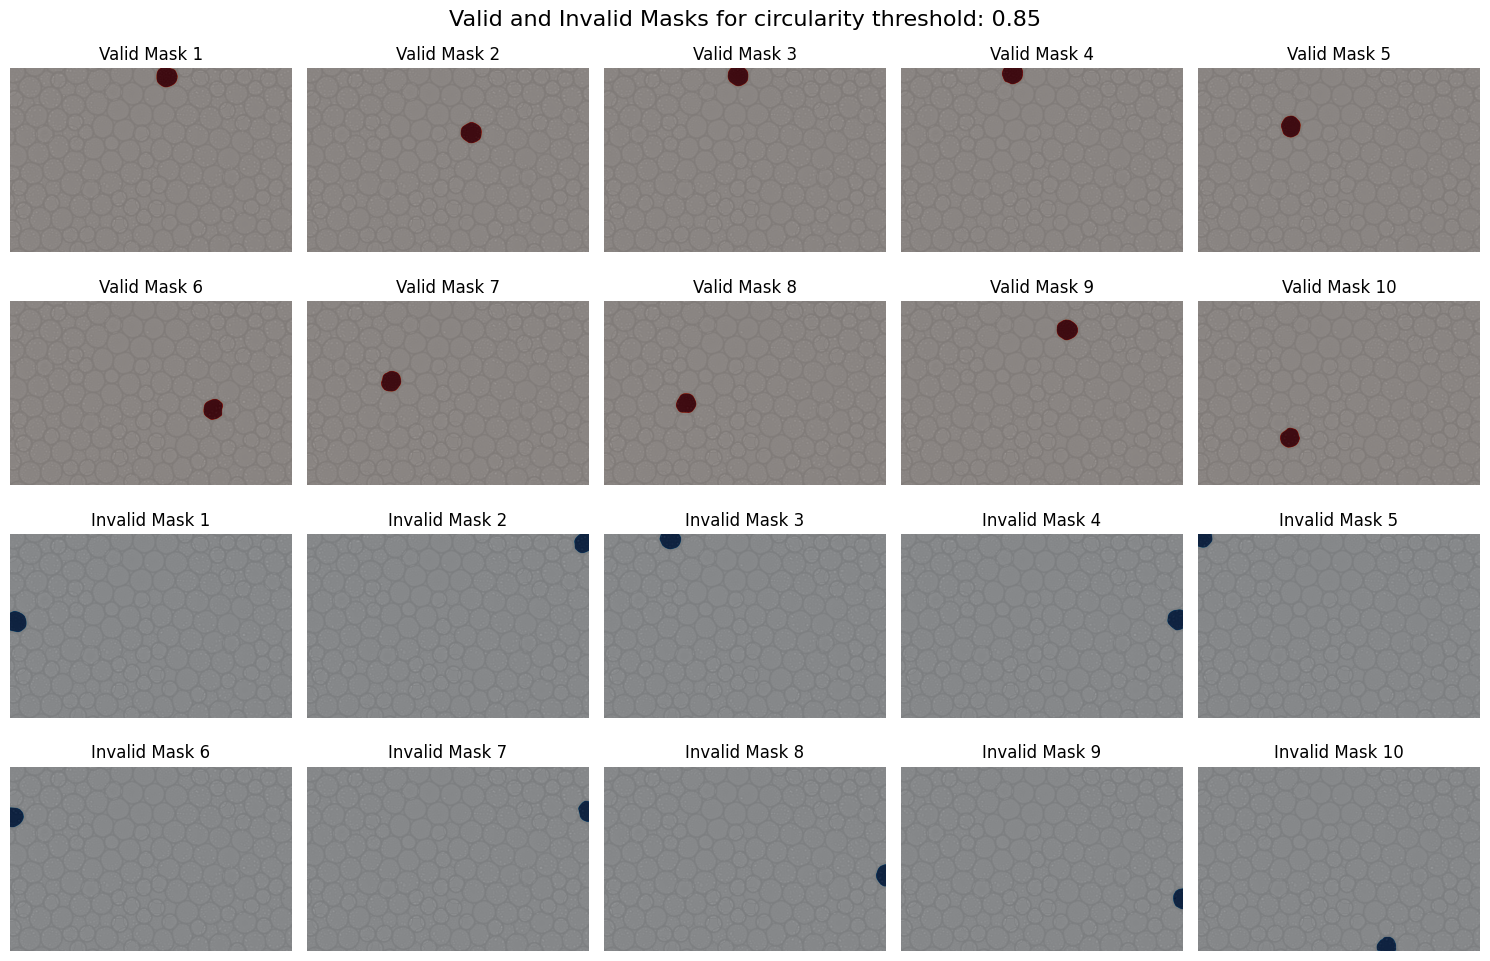

In [ ]:

# Exemple d'utilisation
plot_circularity_validation(dic_roi, masks, circularity_threshold=0.85)

In [20]:
def plot_edges_validation(dic_roi, masks, roi_width, roi_height, margin=2):
    """
    Affiche jusqu'à 5 masques valides (non proches des bords) et 10 masques invalides (proches des bords)
    superposés sur l'image DIC.

    Args:
        dic_roi: Image DIC (déjà extraite sous forme de tableau NumPy).
        masks: Liste de masques générés.
        roi_width: Largeur de la ROI.
        roi_height: Hauteur de la ROI.
        margin: Marge minimale pour considérer qu'un masque est trop proche des bords.
    """
    if dic_roi is None:
        print("Erreur : L'image DIC (dic_roi) est invalide.")
        return

    # Séparer les masques valides et invalides
    valid_masks = []
    invalid_masks = []

    for mask in masks:
        bbox = mask['bbox']  # [x_min, y_min, width, height]
        x_min, y_min, width, height = bbox
        x_max = x_min + width
        y_max = y_min + height

        # Vérifier si le masque est trop proche des bords
        if x_min < margin or y_min < margin or x_max > roi_width - margin or y_max > roi_height - margin:
            invalid_masks.append(mask)
        else:
            valid_masks.append(mask)

        # Limiter à 5 masques valides et 10 masques invalides
        if len(valid_masks) >= 5 and len(invalid_masks) >= 10:
            break

    # Nombre total de subplots nécessaires
    total_plots = len(valid_masks[:5]) + len(invalid_masks[:10])
    rows = (total_plots + 4) // 5  # Calculer dynamiquement le nombre de lignes (5 colonnes par ligne)

    # Créer la figure
    plt.figure(figsize=(15, 5 * rows))

    # Afficher les masques valides
    for i, mask in enumerate(valid_masks[:5]):
        plt.subplot(rows, 5, i + 1)
        plt.imshow(dic_roi)
        segmentation = mask['segmentation']
        plt.imshow(segmentation, cmap='Greens', alpha=0.5)  # Superposer le masque en vert
        plt.title(f"Valid Mask {i + 1}")
        plt.axis('off')

    # Afficher les masques invalides
    for i, mask in enumerate(invalid_masks[:10]):
        plt.subplot(rows, 5, len(valid_masks[:5]) + i + 1)
        plt.imshow(dic_roi)
        segmentation = mask['segmentation']
        plt.imshow(segmentation, cmap='Oranges', alpha=0.5)  # Superposer le masque en orange
        plt.title(f"Invalid Mask {i + 1}")
        plt.axis('off')
    plt.suptitle("Valid and Invalid Masks near ROI edges for margin = " + str(margin), fontsize=16)
    plt.tight_layout()
    plt.show()



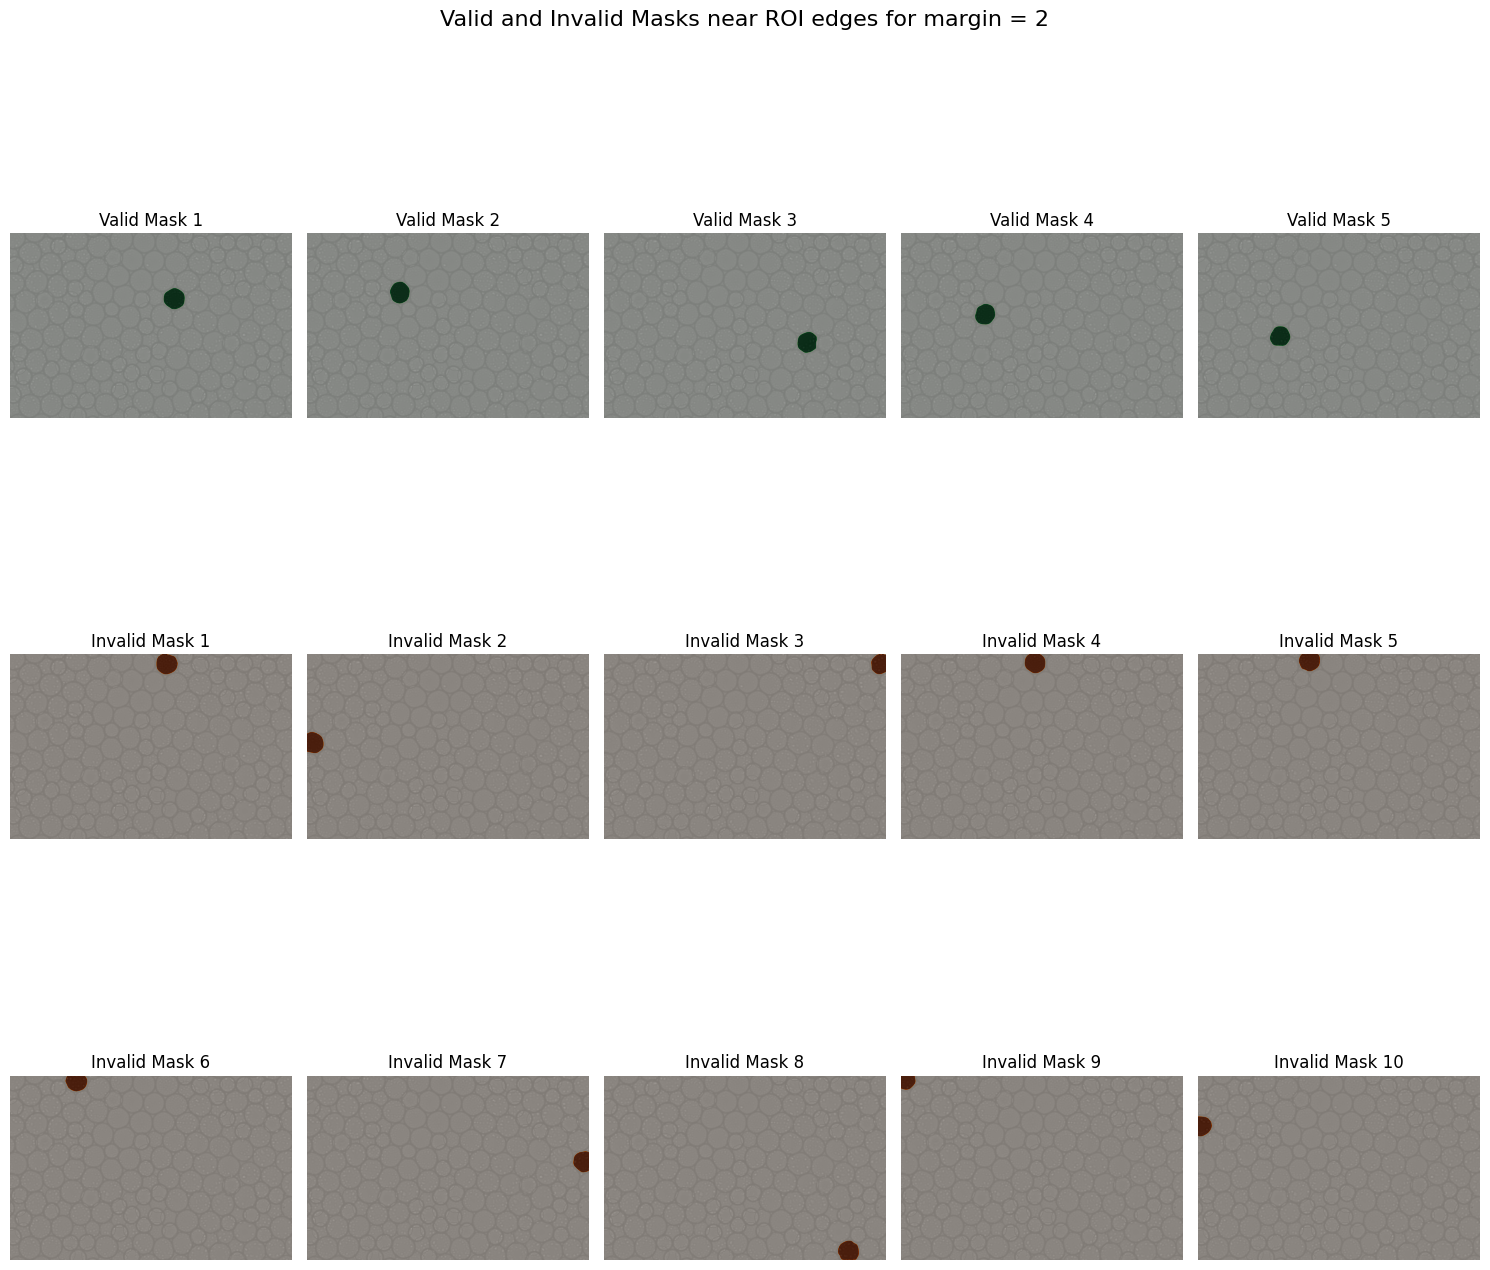

In [ ]:
# Exemple d'utilisation
roi_width, roi_height = dic_roi.shape[1], dic_roi.shape[0]  # Largeur et hauteur de la ROI
plot_edges_validation(dic_roi, masks, roi_width, roi_height, margin=2)

In [21]:
def plot_all_valid_masks(dic_roi, masks, roi_width, roi_height, margin=2, circularity_threshold=0.8):
    """
    Filtre les masques en fonction de leur marge et de leur circularité, puis affiche tous les masques valides
    superposés sur l'image DIC en utilisant show_anns.

    Args:
        dic_roi: Image DIC (déjà extraite sous forme de tableau NumPy).
        masks: Liste de masques générés.
        roi_width: Largeur de la ROI.
        roi_height: Hauteur de la ROI.
        margin: Marge minimale pour considérer qu'un masque est trop proche des bords.
        circularity_threshold: Seuil de circularité pour valider un masque.
    """
    if dic_roi is None:
        print("Erreur : L'image DIC (dic_roi) est invalide.")
        return

    # Liste des masques valides
    valid_masks = []

    for mask in masks:
        # Vérifier la marge (proximité des bords)
        bbox = mask['bbox']  # [x_min, y_min, width, height]
        x_min, y_min, width, height = bbox
        x_max = x_min + width
        y_max = y_min + height

        if x_min < margin or y_min < margin or x_max > roi_width - margin or y_max > roi_height - margin:
            continue  # Masque trop proche des bords, on l'ignore

        # Vérifier la circularité
        circularity = calculate_circularity(mask)
        if circularity is None or circularity < circularity_threshold:
            continue  # Masque non valide en circularité, on l'ignore

        # Ajouter le masque à la liste des masques valides
        valid_masks.append(mask)

    # Afficher tous les masques valides avec show_anns
    if len(valid_masks) == 0:
        print("Aucun masque valide trouvé.")
        return

    plt.figure(figsize=(10, 10))
    plt.imshow(dic_roi)
    show_anns(valid_masks)  # Afficher les masques valides superposés
    plt.axis('off')
    plt.title("Tous les masques valides")
    plt.show()
    return valid_masks

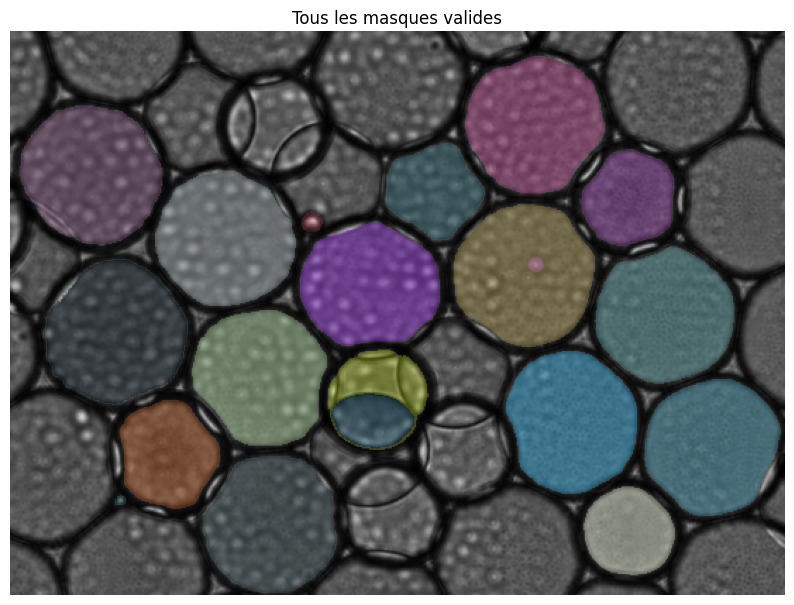

In [25]:
# Exemple d'utilisation
roi_width, roi_height = dic_roi.shape[1], dic_roi.shape[0]  # Largeur et hauteur de la ROI
x = plot_all_valid_masks(dic_roi, masks, roi_width, roi_height, margin=3, circularity_threshold=0.8)
np.save('valid_masks_fbnotebook.npy', x)

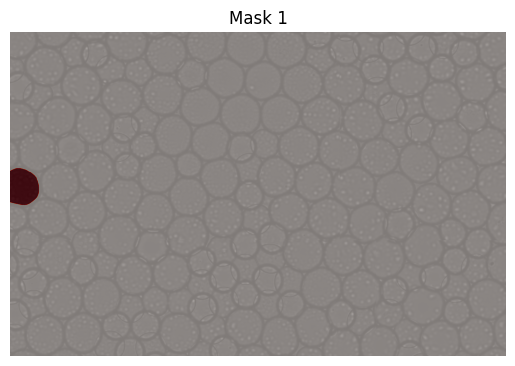

In [83]:
# afficher le masque 1
plt.figure()
plt.imshow(dic_roi)
plt.imshow(masks[1]['segmentation'], cmap='Reds', alpha=0.5)
plt.axis('off')
plt.title("Mask 1")
plt.show()

In [ ]:
def calculate_centroid(bbox):
    """
    Calcule le centroïde d'une boîte englobante (bbox).
    
    Args:
        bbox: Liste [x_min, y_min, width, height].
    
    Returns:
        Tuple (x_centroid, y_centroid).
    """
    x_min, y_min, width, height = bbox
    x_centroid = x_min + width / 2
    y_centroid = y_min + height / 2
    return x_centroid, y_centroid

def is_duplicate(mask1, mask2):
    """
    Vérifie si deux masques sont des doublons en comparant leurs centroïdes.
    
    Args:
        mask1: Premier masque (dictionnaire avec 'bbox').
        mask2: Deuxième masque (dictionnaire avec 'bbox').
    
    Returns:
        True si les masques sont des doublons, False sinon.
    """
    centroid1 = calculate_centroid(mask1['bbox'])
    centroid2 = calculate_centroid(mask2['bbox'])
    distance = np.sqrt((centroid1[0] - centroid2[0])**2 + (centroid1[1] - centroid2[1])**2)
    margin = max(mask1['bbox'][2], mask2['bbox'][2]) * 0.2
    return distance <= margin



In [ ]:
def process_image(image, roi_size, overlap, mask_generator, circularity_threshold=0.85, margin=2):
    """
    Parcourt une image entière avec des ROIs qui se chevauchent, génère des masques, et filtre les doublons.

    Args:
        image_path: Chemin de l'image.
        roi_size: Taille des ROIs (largeur, hauteur).
        overlap: Pourcentage de chevauchement entre les ROIs (valeur entre 0 et 1).
        mask_generator: Générateur de masques (par exemple, SamAutomaticMaskGenerator).
        circularity_threshold: Seuil minimal de circularité pour accepter un masque.
        margin: Marge pour considérer deux masques comme des doublons (en pixels).

    Returns:
        Une liste de masques valides pour l'image entière.
    """
    if image is None:
        print(f"Erreur : Impossible de lire l'image à partir du chemin : {image_path}")
        return []

    image_height, image_width = image.shape[:2]
    roi_width, roi_height = roi_size

    # Calculer le pas (stride) en fonction du chevauchement
    stride_x = int(roi_width * (1 - overlap))
    stride_y = int(roi_height * (1 - overlap))

    all_masks = []
    for y in range(0, image_height, stride_y):
        for x in range(0, image_width, stride_x):
            # Ajuster les dimensions de la ROI pour inclure les pixels restants
            x_min, y_min = x, y
            x_max = min(x + roi_width, image_width)
            y_max = min(y + roi_height, image_height)

            # Extraire la ROI
            roi = image[y_min:y_max, x_min:x_max]
            if roi.size == 0:
                continue
            print(f"Traitement de la ROI : x_min={x_min}, y_min={y_min}, x_max={x_max}, y_max={y_max}")
            # Générer les masques pour la ROI
            print("Generating masks...")
            masks = mask_generator.generate(roi)
            print(f"Nombre de masques générés : {len(masks)}")
            for mask in masks:

                # vérifier la non juxtaposition avec les bords de la ROI
                if mask['bbox'][0] < margin or mask['bbox'][1] < margin or \
                   mask['bbox'][0] + mask['bbox'][2] > roi_width - margin or \
                   mask['bbox'][1] + mask['bbox'][3] > roi_height - margin:
                    continue

                # Vérifier la circularité
                circularity = calculate_circularity(mask)
                if circularity is None or circularity < circularity_threshold:
                    continue

                # Vérifier les doublons avec les masques déjà ajoutés
                is_duplicate_mask = any(is_duplicate(mask, existing_mask) for existing_mask in all_masks)
                if is_duplicate_mask:
                    continue
                

                # Ajouter le masque à la liste globale
                all_masks.append(mask)

    return all_masks



In [ ]:
recomposed_masks = process_image(dic_roi, roi_size=(1500,1200), overlap=0.3, mask_generator=mask_generator)

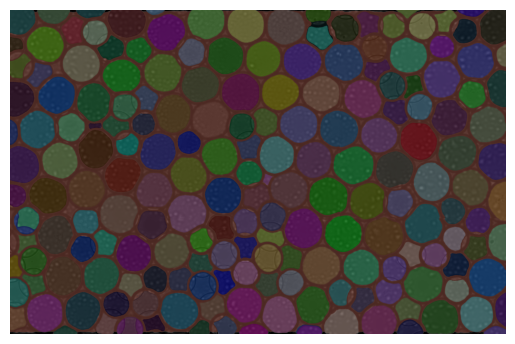

In [10]:
plt.figure()
plt.imshow(dic_roi)
show_anns(masks)
plt.axis('off')
plt.show()

## traitement

In [30]:
# shape de fluo = shape de dic

import cv2

fluo = cv2.imread(fluo_path)
dic = cv2.imread(dic_path)

if fluo is None or dic is None:
    print("Error: Could not load one or both images.")
else:
    if fluo.shape == dic.shape:
        print("The shapes of fluo and dic are the same.")
    else:
        print("The shapes of fluo and dic are different.")
        print(f"fluo shape: {fluo.shape}, dic shape: {dic.shape}")

The shapes of fluo and dic are the same.


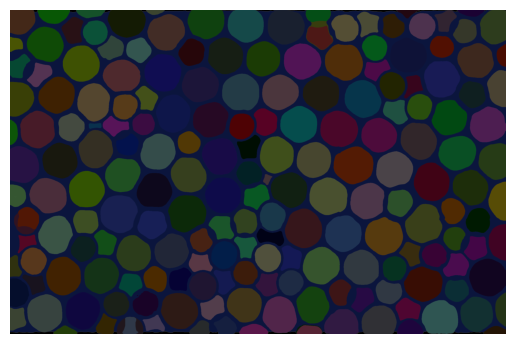

In [15]:
fluo_roi = extract_roi(fluo_path, 0, 0, 2600, 1700)
#fluo_roi = cv2.normalize(fluo_roi, None, 0, 255, cv2.NORM_MINMAX)

plt.figure()
plt.imshow(fluo_roi)
show_anns(masks)
plt.axis('off')
plt.show()

In [16]:
# prompt: calculer la fluorescence moyenne dans une cellule sur fluo.tif, délimitée par le masque fait à partir de droplet.png


def calculate_average_fluorescence(fluo_image, mask):
    """Calculates the average fluorescence intensity within a given mask.

    Args:
        fluo_image: NumPy array representing the fluorescence image.
        mask: NumPy array representing the binary mask (0 or 1).

    Returns:
        The average fluorescence intensity within the mask, or NaN if the mask is empty.
    """
    masked_fluorescence = fluo_image[mask > 0]
    if len(masked_fluorescence) == 0:
        return np.nan  # Return NaN if the mask doesn't cover any pixels
    return np.mean(masked_fluorescence)


In [ ]:
mask_index = 0
for mask in masks:
    current_mask = mask['segmentation']
    average_fluo = calculate_average_fluorescence(fluo_roi, current_mask)

    if np.isnan(average_fluo):
        print(f"Mask {mask_index} is empty. Cannot calculate average fluorescence.")
    else:
        print(f"Average fluorescence in mask {mask_index}: {average_fluo}")
    mask_index += 1


In [22]:
# prompt: parcourir les fichiers EFGP en faisant varier de 't081' à 't091' dans le nom du path, calculer les fluorescences pour chaque masque (définit plus tôt sous mask) et les stocker dans un tableau. le but est de plot l'évolution des fluorescences en fonction du temps pour chaque masque, sur une même figure
timepoint1= 75
timepoint2 = 99
# les coordonnées de ROI sont fixées

In [ ]:
fluorescence_values = []
fluo_path1 = 'SBW25WTGFP_CAAIPTG_1_100cell_droplet-04/SBW25WTGFP_CAAIPTG_1_100cell_droplet-04_'
fluo_path2 = '_EGFP_ORG.tif'
for i in range(timepoint1, timepoint2):  # Iterate from t??? to t???
    timepoint = f"t0{i}"
    fluo_path = fluo_path1 + f'{timepoint}' + fluo_path2
    try:
        fluo_roi = extract_roi(fluo_path, x_min, y_min, x_max, y_max)

        if dic_roi is not None and fluo_roi is not None:

            timepoint_fluorescence = []
            for mask in masks:
                average_fluo = calculate_average_fluorescence(fluo_roi, mask['segmentation'])
                timepoint_fluorescence.append(average_fluo)
            fluorescence_values.append(timepoint_fluorescence)
            print(f"Processed timepoint {timepoint}")
        else:
          print(f"Skipping timepoint {timepoint} due to image loading error")
    except Exception as e:
        print(f"Error processing timepoint {timepoint}: {e}")


Processed timepoint t075
Processed timepoint t076
Processed timepoint t077
Processed timepoint t078
Processed timepoint t079
Processed timepoint t080
Processed timepoint t081
Processed timepoint t082
Processed timepoint t083
Processed timepoint t084
Processed timepoint t085
Processed timepoint t086
Processed timepoint t087
Processed timepoint t088
Processed timepoint t089
Processed timepoint t090
Processed timepoint t091
Processed timepoint t092
Processed timepoint t093
Processed timepoint t094
Processed timepoint t095
Processed timepoint t096
Processed timepoint t097
Processed timepoint t098


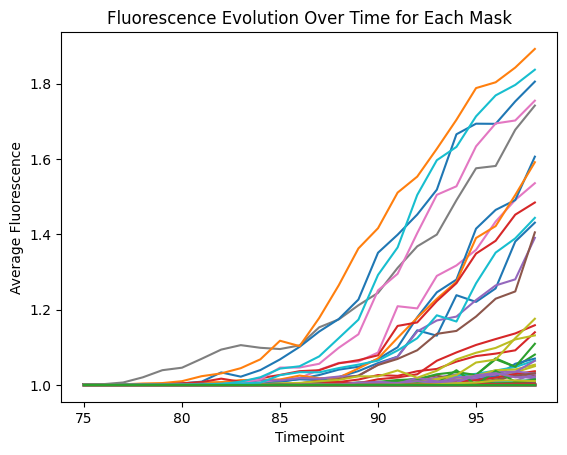

In [24]:
timepoints = [i for i in range(timepoint1, timepoint2)]
for i in range(len(fluorescence_values[0])):  # Iterate over each mask
    mask_fluorescence = [fluorescence_values[j][i] if i < len(fluorescence_values[j]) else None for j in range(len(fluorescence_values))]
    plt.plot(timepoints, mask_fluorescence, label=f"Mask {i+1}")


plt.xlabel("Timepoint")
plt.ylabel("Average Fluorescence")
plt.title("Fluorescence Evolution Over Time for Each Mask")
plt.show()